# 03 — Saliency Maps & Explainability

CV attribution heatmaps (always runnable), Grad-CAM (requires PyTorch + trained model), and a ResNet-18 training pipeline modelled on `mint_condition`.

**Prerequisite:** `grading_utils.py` must exist.

## Setup

In [ ]:
# ── Install dependencies ─────────────────────────────────────────
import subprocess, sys
packages = ['ultralytics','opencv-python','numpy','Pillow',
            'matplotlib','scipy','scikit-image','scikit-learn']
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + packages)

# ── Core functions ───────────────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('grading_utils.py')))
from grading_utils import *

# ── Accuracy improvement helpers (inline — no circular import) ───
import cv2, numpy as np

def normalize_lighting(image):
    if image.size == 0: return image
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    corrected = cv2.cvtColor(cv2.merge([clahe.apply(l), a, b]), cv2.COLOR_LAB2BGR)
    b_m,g_m,r_m = np.mean(corrected[:,:,0]),np.mean(corrected[:,:,1]),np.mean(corrected[:,:,2])
    mu = (b_m+g_m+r_m)/3
    bal = corrected.astype(np.float32)
    bal[:,:,0]*=mu/max(b_m,1); bal[:,:,1]*=mu/max(g_m,1); bal[:,:,2]*=mu/max(r_m,1)
    return np.clip(bal,0,255).astype(np.uint8)

def remove_glare(image, threshold=242):
    mask=((image[:,:,0]>threshold)&(image[:,:,1]>threshold)&(image[:,:,2]>threshold)).astype(np.uint8)*255
    if mask.sum()==0: return image
    k=cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(7,7))
    return cv2.inpaint(image,cv2.dilate(mask,k,iterations=2),9,cv2.INPAINT_NS)

def grade_card_v2(image_path, yolo_model=None, normalize=True, skip_quality_check=True):
    _, card, method = extract_card(image_path, yolo_model)
    if normalize:
        card = remove_glare(card)
        card = normalize_lighting(card)
    centering = analyze_centering(card)
    corners   = analyze_corners(card)
    edges     = analyze_edges(card)
    surface   = analyze_surface(card)
    corner_score = corners.mean*0.4 + corners.worst*0.6
    edge_score   = edges.mean*0.5   + edges.worst*0.5
    sub = {'corners':corner_score,'centering':centering.score,
           'edges':edge_score,'surface':surface.score}
    composite = sum(sub[k]*WEIGHTS[k] for k in WEIGHTS)
    psa_est   = composite_to_psa(composite, corners.worst)
    psa_int   = int(psa_est)
    return GradeReport(str(image_path),centering,corners,edges,surface,sub,
                       composite,float(psa_est),
                       f'PSA {psa_int} ({PSA_LABELS[psa_int]})',
                       'Low' if method=='center_crop' else 'High'), {}

%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi']      = 120
plt.rcParams['axes.facecolor']  = '#0d1117'
plt.rcParams['figure.facecolor']= '#0d1117'
plt.rcParams['text.color']      = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color']     = 'white'
plt.rcParams['ytick.color']     = 'white'

try:
    from ultralytics import YOLO
    yolo_model = YOLO('yolov8n-seg.pt')
    print('✅ YOLOv8 loaded')
except Exception:
    yolo_model = None

print('✅ Saliency & explainability notebook ready')

## 23. Saliency Maps — Visual Explanation

Two complementary views of *why* the model assigned a grade:

### A. CV Attribution Heatmap (always available)
Spatially overlays each sub-analyzer's score directly onto the card:
- **Corners** (10 % patches at each corner) — colored green→red by corner score
- **Edges** (5 % strips) — colored by edge score
- **Surface** (inner artwork region) — colored by surface score
- **Centering borders** — detected boundary lines drawn in amber

### B. Grad-CAM on ResNet-18 (requires PyTorch + a trained model)
Standard gradient-weighted class activation map showing which pixels
a CNN attended to. Useful once you have a trained deep model (see
Section 24 for the training pipeline inspired by `mint_condition`).

In [25]:
def score_to_bgr(score: float) -> tuple:
    """Map 0-100 score to BGR color: red(0) → amber(50) → green(100)."""
    score = float(np.clip(score, 0, 100))
    if score >= 70:
        # green zone: interpolate green → bright green
        t = (score - 70) / 30.0
        r = int(0   * (1-t) + 0   * t)
        g = int(200 * (1-t) + 255 * t)
        b = int(50  * (1-t) + 50  * t)
    elif score >= 40:
        # amber zone: interpolate amber → green
        t = (score - 40) / 30.0
        r = int(0   * (1-t) + 0   * t)
        g = int(160 * (1-t) + 200 * t)
        b = int(200 * (1-t) + 50  * t)
    else:
        # red zone
        t = score / 40.0
        r = int(50  * (1-t) + 0   * t)
        g = int(50  * (1-t) + 160 * t)
        b = int(200 * (1-t) + 200 * t)
    return (b, g, r)


def build_cv_heatmap(card: np.ndarray, report: GradeReport,
                     alpha: float = 0.45) -> np.ndarray:
    """
    Overlay per-region scores as a semi-transparent color mask on the card.

    Regions
    -------
    - 4 corner patches  → colored by individual corner score
    - 4 edge strips     → colored by individual edge score
    - inner surface     → colored by surface score
    - centering lines   → amber lines showing detected border positions
    """
    h, w = card.shape[:2]
    overlay = card.copy().astype(np.float32)
    mask    = np.zeros((h, w, 3), dtype=np.float32)

    cp = int(h * 0.10)   # corner patch size (10 %)
    cw = int(w * 0.10)
    ep_h = max(4, int(h * 0.05))   # edge strip thickness
    ep_w = max(4, int(w * 0.05))

    # ── Corner regions ────────────────────────────────────────────
    corner_coords = [
        (slice(0, cp),    slice(0, cw)),     # TL
        (slice(0, cp),    slice(w-cw, w)),   # TR
        (slice(h-cp, h),  slice(0, cw)),     # BL
        (slice(h-cp, h),  slice(w-cw, w)),   # BR
    ]
    for (rs, cs), score in zip(corner_coords, report.corners.scores):
        color = np.array(score_to_bgr(score), dtype=np.float32)
        mask[rs, cs] = color

    # ── Edge strips (excluding corners) ──────────────────────────
    edge_regions = [
        (slice(0, ep_h),      slice(cw, w-cw)),   # top
        (slice(ep_h, h-ep_h), slice(w-ep_w, w)),  # right
        (slice(h-ep_h, h),    slice(cw, w-cw)),   # bottom
        (slice(ep_h, h-ep_h), slice(0, ep_w)),    # left
    ]
    for (rs, cs), score in zip(edge_regions, report.edges.scores):
        color = np.array(score_to_bgr(score), dtype=np.float32)
        mask[rs, cs] = color

    # ── Surface / artwork area ────────────────────────────────────
    surf_color = np.array(score_to_bgr(report.surface.score), dtype=np.float32)
    mask[ep_h:h-ep_h, ep_w:w-ep_w] = surf_color

    # ── Blend: overlay = card * (1-alpha) + mask * alpha ─────────
    blended = (card.astype(np.float32) * (1-alpha) +
               mask * alpha).clip(0, 255).astype(np.uint8)

    # ── Centering borders (amber lines) ──────────────────────────
    cen = report.centering
    top_y    = int(cen.top_pct    * h)
    bot_y    = int((1 - cen.bottom_pct) * h)
    left_x   = int(cen.left_pct  * w)
    right_x  = int((1 - cen.right_pct) * w)
    amber = (0, 165, 255)   # BGR amber
    lw = max(2, h // 200)
    cv2.line(blended, (0, top_y),   (w, top_y),   amber, lw)
    cv2.line(blended, (0, bot_y),   (w, bot_y),   amber, lw)
    cv2.line(blended, (left_x, 0),  (left_x, h),  amber, lw)
    cv2.line(blended, (right_x, 0), (right_x, h), amber, lw)

    # ── Score labels on each region ───────────────────────────────
    label_positions = [
        # corners
        (int(cw*0.15),   int(cp*0.7),   report.corners.scores[0], 'TL'),
        (int(w-cw*0.85), int(cp*0.7),   report.corners.scores[1], 'TR'),
        (int(cw*0.15),   int(h-cp*0.4), report.corners.scores[2], 'BL'),
        (int(w-cw*0.85), int(h-cp*0.4), report.corners.scores[3], 'BR'),
    ]
    for (x, y, sc, lbl) in label_positions:
        cv2.putText(blended, f'{lbl} {sc:.0f}',
                    (x, y), cv2.FONT_HERSHEY_SIMPLEX,
                    max(0.3, h/2000), (255, 255, 255), 1, cv2.LINE_AA)

    return blended


def plot_saliency_cv(image_path: str, report: GradeReport = None):
    """
    Full saliency dashboard: original card, heatmap overlay, and score legend.
    Pass a pre-computed report or let the function grade the card first.
    """
    _, card, _ = extract_card(image_path)

    if report is None:
        report, _ = grade_card_v2(image_path, normalize=True,
                                   skip_quality_check=True)

    heatmap = build_cv_heatmap(card, report)

    # ── Score legend bar ─────────────────────────────────────────
    bar_h, bar_w = 30, card.shape[1]
    legend = np.zeros((bar_h, bar_w, 3), dtype=np.uint8)
    for x in range(bar_w):
        score = x / bar_w * 100
        legend[:, x] = score_to_bgr(score)[::-1]   # BGR→RGB handled by imshow
    for score, label in [(0, '0'), (50, '50'), (70, '70'), (100, '100')]:
        x = int(score / 100 * bar_w)
        cv2.putText(legend, label, (max(0, x-8), 22),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 8),
                              gridspec_kw={'width_ratios': [1, 1, 0.55]})
    fig.patch.set_facecolor('#0d1117')

    # Original
    axes[0].imshow(cv2.cvtColor(card, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original', color='white', fontsize=11)
    axes[0].axis('off')

    # Heatmap
    axes[1].imshow(cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB))
    axes[1].set_title(
        f'CV Attribution Heatmap  ·  {report.psa_label}', color='white', fontsize=11)
    axes[1].axis('off')

    # Score card panel
    ax = axes[2]
    ax.set_facecolor('#161b22')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title('Region Scores', color='white', fontsize=11)

    rows = [
        ('Corner TL',  report.corners.scores[0]),
        ('Corner TR',  report.corners.scores[1]),
        ('Corner BL',  report.corners.scores[2]),
        ('Corner BR',  report.corners.scores[3]),
        ('Edge Top',   report.edges.scores[0] if len(report.edges.scores)>0 else 0),
        ('Edge Right', report.edges.scores[1] if len(report.edges.scores)>1 else 0),
        ('Edge Bot',   report.edges.scores[2] if len(report.edges.scores)>2 else 0),
        ('Edge Left',  report.edges.scores[3] if len(report.edges.scores)>3 else 0),
        ('Surface',    report.surface.score),
        ('Centering',  report.centering.score),
        ('─'*18, None),
        ('Composite',  report.composite),
    ]

    y = 0.97
    for label, score in rows:
        if score is None:
            ax.axhline(y + 0.01, color='#30363d', lw=0.8, xmin=0.02, xmax=0.98)
            y -= 0.045
            continue
        r_norm, g_norm, b_norm = [c/255 for c in score_to_bgr(score)[::-1]]
        clr = (r_norm, g_norm, b_norm)
        # Mini bar
        ax.barh(y, score/100 * 0.55, height=0.055, left=0.43,
                color=clr, alpha=0.85)
        ax.text(0.02, y, label,    color='#8b949e', fontsize=8, va='center')
        ax.text(0.38, y, f'{score:.0f}', color=clr,   fontsize=8, va='center', ha='right')
        y -= 0.075

    plt.tight_layout()
    plt.show()


print('✅ CV attribution heatmap ready — call plot_saliency_cv(IMAGE_PATH, report)')

✅ CV attribution heatmap ready — call plot_saliency_cv(IMAGE_PATH, report)


### B. Grad-CAM on a Trained ResNet-18

Requires **PyTorch** and a trained model checkpoint. Once you have a model
(trained via Section 24's pipeline), this shows gradient-weighted class
activation maps on the card image — the same technique used by `mint_condition`.

In [26]:
def gradcam_heatmap(model, image_path: str, target_layer_name: str = 'layer4',
                    target_class: int = None) -> np.ndarray:
    """
    Compute Grad-CAM heatmap for a ResNet-style model.

    Parameters
    ----------
    model            : trained torchvision ResNet (any variant)
    image_path       : path to card photo
    target_layer_name: conv layer to hook (default 'layer4' — deepest ResNet block)
    target_class     : class index to explain (None = argmax of prediction)

    Returns
    -------
    heatmap: BGR uint8 image, same size as input card
    """
    try:
        import torch
        import torch.nn.functional as F
        from torchvision import transforms
    except ImportError:
        print('PyTorch not installed — run: pip install torch torchvision')
        return None

    _, card, _ = extract_card(image_path)
    card_rgb   = cv2.cvtColor(card, cv2.COLOR_BGR2RGB)
    h, w       = card.shape[:2]

    # ── Preprocess ────────────────────────────────────────────────
    preprocess = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((255, 255)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ])
    inp = preprocess(card_rgb).unsqueeze(0)   # (1, 3, 255, 255)

    # ── Hook to capture activations and gradients ─────────────────
    activations, gradients = [], []

    def fwd_hook(module, input, output):
        activations.append(output.detach())

    def bwd_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0].detach())

    target_layer = dict(model.named_modules())[target_layer_name]
    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    # ── Forward pass ──────────────────────────────────────────────
    model.eval()
    with torch.enable_grad():
        logits = model(inp)
        if target_class is None:
            target_class = int(logits.argmax(dim=1))
        score = logits[0, target_class]
        model.zero_grad()
        score.backward()

    h1.remove(); h2.remove()

    # ── Grad-CAM weights: global average pool of gradients ────────
    grads  = gradients[0].squeeze(0)   # (C, H_feat, W_feat)
    acts   = activations[0].squeeze(0) # (C, H_feat, W_feat)
    weights = grads.mean(dim=(1, 2))   # (C,)

    cam = (weights[:, None, None] * acts).sum(dim=0)
    cam = F.relu(cam)

    # Normalize and resize to card dimensions
    cam = cam.numpy()
    cam -= cam.min()
    if cam.max() > 0:
        cam /= cam.max()
    cam_resized = cv2.resize(cam, (w, h))

    # Convert to BGR heatmap
    heatmap_uint8 = (cam_resized * 255).astype(np.uint8)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    # Overlay on original card
    overlay = cv2.addWeighted(card, 0.55, heatmap_color, 0.45, 0)

    return overlay, cam_resized, target_class


def plot_gradcam(model, image_path: str, class_names: list = None):
    """
    Show Grad-CAM overlay for the predicted class alongside the original card.
    """
    result = gradcam_heatmap(model, image_path)
    if result is None:
        return
    overlay, cam, pred_class = result
    _, card, _ = extract_card(image_path)

    label = class_names[pred_class] if class_names else f'class {pred_class}'

    fig, axes = plt.subplots(1, 3, figsize=(18, 7))
    fig.patch.set_facecolor('#0d1117')

    axes[0].imshow(cv2.cvtColor(card, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original', color='white')
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'Grad-CAM  →  Predicted: {label}', color='white')
    axes[1].axis('off')

    axes[2].imshow(cam, cmap='jet')
    axes[2].set_title('Raw Activation Map', color='white')
    axes[2].axis('off')
    axes[2].figure.colorbar(
        plt.cm.ScalarMappable(cmap='jet'),
        ax=axes[2], fraction=0.046, pad=0.04
    ).ax.yaxis.set_tick_params(color='white')

    plt.suptitle('Grad-CAM Saliency — which card regions drove the prediction',
                 color='white', fontsize=12)
    plt.tight_layout()
    plt.show()


# ── Usage example (requires trained model) ────────────────────────
print('✅ Grad-CAM ready')
print()
print('Usage (once you have a trained ResNet):')
print('  from torchvision.models import resnet18')
print('  model = resnet18(num_classes=5)')
print('  model.load_state_dict(torch.load("resnet18_grader.pt"))')
print('  plot_gradcam(model, IMAGE_PATH, class_names=["Poor","VG","EX","NM","Mint"])')

✅ Grad-CAM ready

Usage (once you have a trained ResNet):
  from torchvision.models import resnet18
  model = resnet18(num_classes=5)
  model.load_state_dict(torch.load("resnet18_grader.pt"))
  plot_gradcam(model, IMAGE_PATH, class_names=["Poor","VG","EX","NM","Mint"])


## 24. ResNet-18 Training Pipeline

Mirrors the `mint_condition` approach: collect eBay images labeled by PSA grade
(parsed from listing titles), fine-tune ResNet-18, evaluate against human baseline.

Key insight from `mint_condition`: training **from scratch** on card-specific
low-level features (scratches, print lines, rounded corners) outperformed
fine-tuning from ImageNet weights. We use **pretrained + fine-tuned** here as a
starting point — experiment with `freeze_backbone=False` for scratch training.

In [27]:
def build_resnet_grader(num_classes: int = 5, pretrained: bool = True,
                        freeze_backbone: bool = False):
    """
    Build a ResNet-18 for card grade classification.

    num_classes: 5 (Poor/VG/EX/NM/Mint buckets, mirrors mint_condition)
                 or 10 (individual PSA grades 1-10)
    freeze_backbone: True = only train the final FC layer (fast, less data needed)
                     False = train all layers (needs more data, potentially better)
    """
    try:
        import torch
        import torch.nn as nn
        from torchvision import models
    except ImportError:
        print('Install PyTorch: pip install torch torchvision')
        return None

    weights = 'IMAGENET1K_V1' if pretrained else None
    model   = models.resnet18(weights=weights)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace final FC layer
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


# PSA 1-10 → 5-bucket mapping (matches mint_condition's framing)
PSA_TO_BUCKET = {1: 0, 2: 0,          # Poor
                 3: 1, 4: 1,          # Very Good
                 5: 2, 6: 2,          # Excellent
                 7: 3, 8: 3,          # Near Mint
                 9: 4, 10: 4}         # Mint
BUCKET_NAMES  = ['Poor', 'Very Good', 'Excellent', 'Near Mint', 'Mint']


def train_resnet_grader(image_dir: str,
                        model_out:  str  = 'resnet18_grader.pt',
                        num_classes: int = 5,
                        epochs:      int = 10,
                        batch_size:  int = 32,
                        lr:          float = 1e-4):
    """
    Fine-tune ResNet-18 on a folder of labeled card images.

    Expected folder structure:
        image_dir/
            psa_1/   (or bucket_0/ if using 5-class)
            psa_2/
            ...
            psa_10/

    Or flat with filenames like: grade_9_page_3_id_42.jpg
    (grade parsed from filename — matches mint_condition naming convention)
    """
    try:
        import torch
        import torch.nn as nn
        from torch.utils.data import Dataset, DataLoader, random_split
        from torchvision import transforms
        from sklearn.metrics import f1_score
        from scipy.stats import spearmanr
    except ImportError:
        print('Install deps: pip install torch torchvision scikit-learn scipy')
        return

    from pathlib import Path

    # ── Dataset ────────────────────────────────────────────────────
    class CardDataset(Dataset):
        def __init__(self, image_dir, transform, num_classes):
            self.samples   = []
            self.transform = transform
            img_dir = Path(image_dir)

            # Support two layouts:
            # 1. Subdirs named psa_9/, grade_9/, 9/
            # 2. Flat files named grade_9_*.jpg
            for path in sorted(img_dir.rglob('*.jpg')) + sorted(img_dir.rglob('*.jpeg')):
                grade = None
                # Try parent folder name
                try:
                    grade = int(''.join(filter(str.isdigit, path.parent.name)))
                except ValueError:
                    pass
                # Try filename prefix
                if grade is None:
                    import re
                    m = re.search(r'grade_(\d+)', path.stem)
                    if m:
                        grade = int(m.group(1))
                if grade and 1 <= grade <= 10:
                    label = PSA_TO_BUCKET[grade] if num_classes == 5 else grade - 1
                    self.samples.append((str(path), label))

        def __len__(self): return len(self.samples)
        def __getitem__(self, idx):
            path, label = self.samples[idx]
            img = cv2.imread(path)
            if img is None:
                img = np.zeros((255, 255, 3), dtype=np.uint8)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            return self.transform(img), label

    train_tf = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((255, 255)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomAffine(degrees=15, shear=10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    val_tf = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((255, 255)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    full_ds = CardDataset(image_dir, train_tf, num_classes)
    if len(full_ds) == 0:
        print(f'No images found in {image_dir}. Check folder layout.'); return

    n_val   = max(1, int(len(full_ds) * 0.10))
    n_train = len(full_ds) - n_val
    train_ds, val_ds = random_split(full_ds, [n_train, n_val])
    val_ds.dataset   = CardDataset(image_dir, val_tf, num_classes)

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    val_dl   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)

    # ── Model & optimizer ─────────────────────────────────────────
    device = 'cuda' if __import__('torch').cuda.is_available() else 'cpu'
    model  = build_resnet_grader(num_classes=num_classes, pretrained=True,
                                  freeze_backbone=False)
    model  = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = __import__('torch').optim.Adam(model.parameters(), lr=lr)
    scheduler = __import__('torch').optim.lr_scheduler.StepLR(
        optimizer, step_size=4, gamma=0.5)

    print(f'Training ResNet-18  |  {len(full_ds)} images  |  '
          f'{num_classes} classes  |  device={device}')
    print(f'{'Epoch':>6} {'Train Acc':>10} {'Val Acc':>9} {'Val F1':>8} '
          f'{'Spearman':>10}')

    import torch
    history = []
    for epoch in range(1, epochs + 1):
        # ── Train ─────────────────────────────────────────────────
        model.train()
        correct = total = 0
        for imgs, labels in train_dl:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
            preds = model(imgs).argmax(1)
            correct += (preds == labels).sum().item()
            total   += len(labels)
        train_acc = correct / max(total, 1)

        # ── Validate ──────────────────────────────────────────────
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_dl:
                imgs = imgs.to(device)
                preds = model(imgs).argmax(1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(labels.numpy())

        val_acc = sum(p==l for p,l in zip(all_preds, all_labels)) / max(len(all_labels), 1)
        val_f1  = f1_score(all_labels, all_preds, average='micro', zero_division=0)
        rho, _  = spearmanr(all_labels, all_preds)

        print(f'{epoch:>6}   {train_acc:>9.1%}   {val_acc:>8.1%}   '
              f'{val_f1:>7.3f}   {rho:>9.3f}')
        history.append({'epoch': epoch, 'train_acc': train_acc,
                        'val_acc': val_acc, 'f1': val_f1, 'spearman': rho})
        scheduler.step()

    # ── Save ──────────────────────────────────────────────────────
    torch.save(model.state_dict(), model_out)
    print(f'\n✅ Model saved → {model_out}')
    print(f'   Best val acc : {max(r["val_acc"] for r in history):.1%}')
    print(f'   Best Spearman: {max(r["spearman"] for r in history):.3f}')
    print(f'   Human baseline (mint_condition): 31.1%')
    return model, history


print('✅ ResNet-18 training pipeline ready')
print()
print('Usage:')
print('  model, history = train_resnet_grader(')
print('      image_dir  = "cards/",   # folder with psa_1/ ... psa_10/ subfolders')
print('      model_out  = "resnet18_grader.pt",')
print('      num_classes= 5,           # 5 buckets (Poor/VG/EX/NM/Mint)')
print('      epochs     = 10,')
print('  )')

✅ ResNet-18 training pipeline ready

Usage:
  model, history = train_resnet_grader(
      image_dir  = "cards/",   # folder with psa_1/ ... psa_10/ subfolders
      model_out  = "resnet18_grader.pt",
      num_classes= 5,           # 5 buckets (Poor/VG/EX/NM/Mint)
      epochs     = 10,
  )


## 25. Demo — Saliency Map on a Real Card

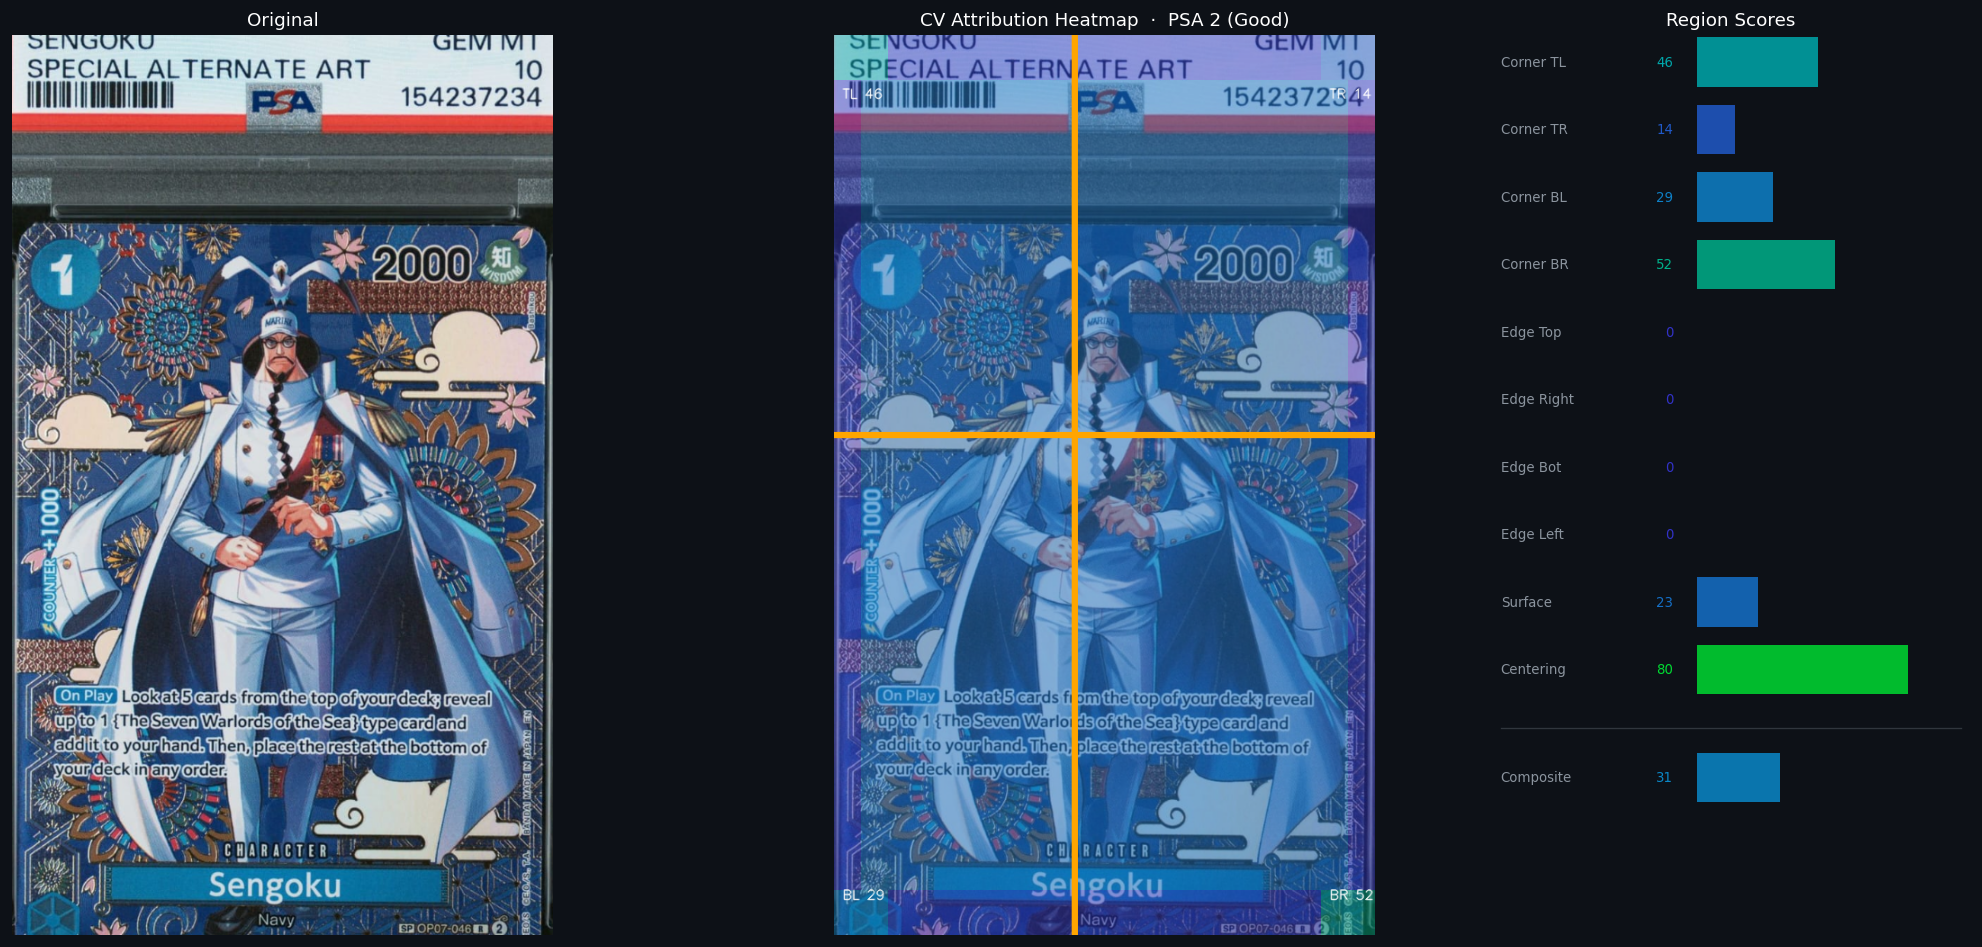

In [28]:
# ── SET IMAGE PATH ────────────────────────────────────────────────
IMAGE_PATH = 'image0_back.jpeg'   # ← change as needed
# ─────────────────────────────────────────────────────────────────

# Grade the card first (reuse if already done in Section 22)
report, _ = grade_card_v2(IMAGE_PATH, yolo_model=yolo_model,
                           card_type='pokemon', skip_quality_check=True)

# CV Attribution Heatmap — always works, no PyTorch required
plot_saliency_cv(IMAGE_PATH, report)